In [1]:
!pip install opencv-python pixellib

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 38.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 45.2 MB/s eta 0:00:0000:0100:01
  DEPRECATION: Building 'fvcore' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` opt

In [2]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.13.0


In [ ]:
# 1. 추론된 마스크를 원본 고양이 이미지 크기로 리사이즈
mask_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

# 2. 고양이 클래스(8)만 선택하여 이진 마스크 생성 (사람인 경우 15로 변경)
cat_mask = np.where(mask_resized == 8, 255, 0).astype(np.uint8)

# 배경 이미지도 고양이 이미지 크기에 맞게 크롭 또는 리사이즈
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

plt.imshow(cat_mask, cmap='gray')
plt.title("Cat Mask")
plt.show()


원본 고양이 이미지 크기: (148, 192, 3)
배경(사막) 이미지 크기: (148, 224, 3)


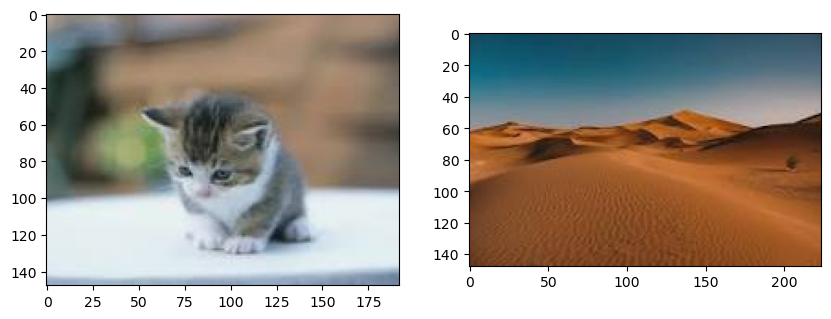

In [10]:
cat_img_path = "cat.jpg"  # 고양이 이미지를 준비해주세요
sand_img_path = "sand.jpg"  # 사막 배경 이미지를 준비해주세요

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [11]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [12]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (148, 192)


In [13]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


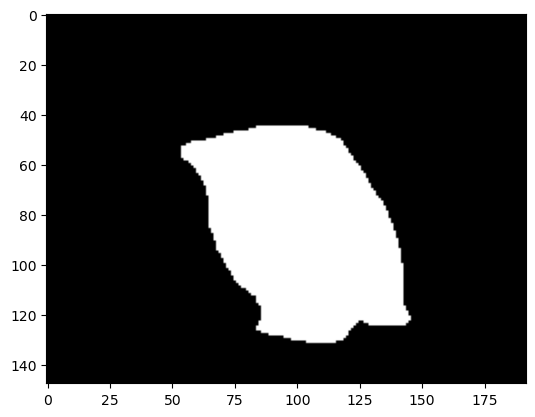

In [14]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

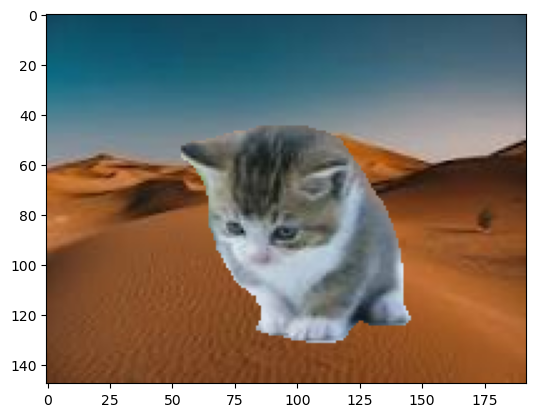

In [15]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

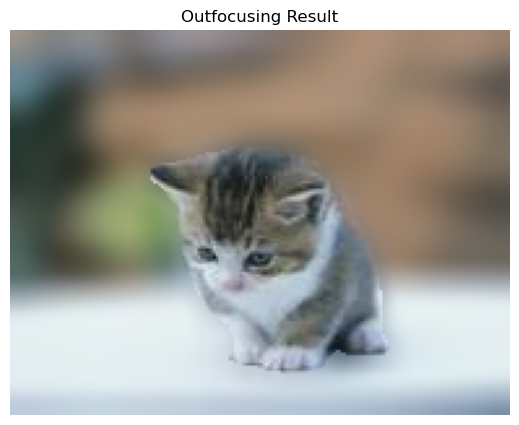

In [18]:
# 원본 이미지를 블러 처리
img_orig_blur = cv2.blur(cat_img, (15, 15))

# 블러 처리된 이미지에서 배경만 추출
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_orig_blur, mask=mask_inv)

# 고양이와 블러 배경 합성
outfocus_result = cv2.add(img_cat_extracted, img_bg_blur)

plt.figure(figsize=(10, 5))
plt.imshow(outfocus_result)
plt.title("Outfocusing Result")
plt.axis('off')
plt.show()

원본 사람 이미지 크기: (3392, 2544, 3)
배경(사막) 이미지 크기: (148, 224, 3)


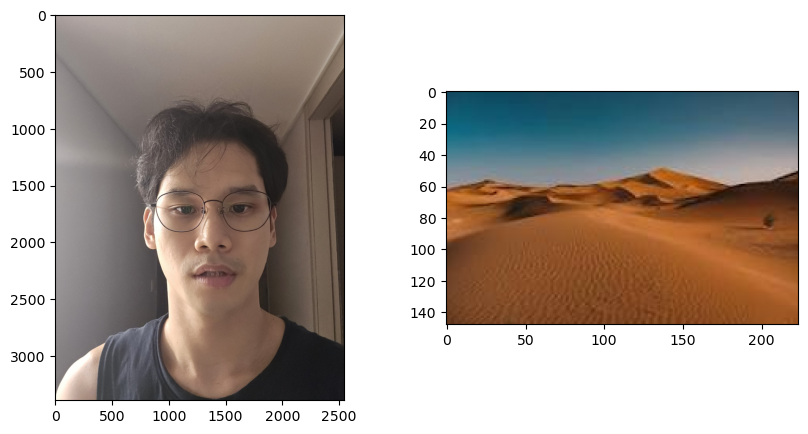

In [26]:
# 1. 원본 셀카 이미지 경로 지정 및 불러오기 
img_selfie = cv2.imread('selfie.jpg')
img_selfie = cv2.cvtColor(img_selfie, cv2.COLOR_BGR2RGB)
img_sand = cv2.imread('sand.jpg')
img_sand = cv2.cvtColor(img_sand, cv2.COLOR_BGR2RGB)

print(f"원본 사람 이미지 크기: {img_selfie.shape}")
print(f"배경(사막) 이미지 크기: {img_sand.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_selfie)

plt.subplot(1, 2, 2)
plt.imshow(img_sand)

plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(img_selfie).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


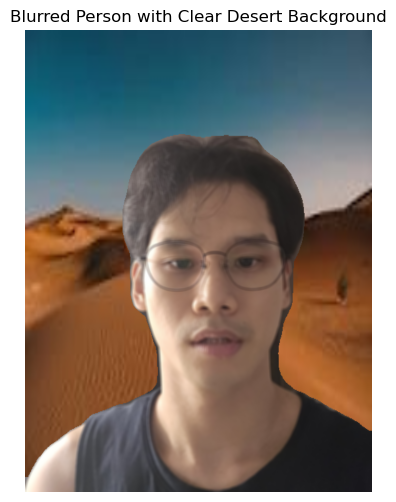

In [33]:
# 2. 추론된 마스크를 셀카 이미지 크기로 리사이즈
mask_resized = cv2.resize(output_predictions, (img_selfie.shape[1], img_selfie.shape[0]), interpolation=cv2.INTER_NEAREST)

# 3. 사람 클래스(15)만 선택하여 이진 마스크 생성
person_mask = np.where(mask_resized == 15, 255, 0).astype(np.uint8)

# 4. 사막 배경 이미지를 셀카 이미지 크기에 맞게 리사이즈
sand_resized = cv2.resize(img_sand, (img_selfie.shape[1], img_selfie.shape[0]))

# 5. 셀카 이미지 전체를 블러(Blur) 처리 (인물 영역을 흐리게 만들기 위함)
# (15, 15) 커널 크기를 조절하여 블러 강도를 바꿀 수 있습니다.
img_selfie_blur = cv2.blur(img_selfie, (25, 25))

# 6. 블러된 셀카 이미지에서 '인물 마스크' 영역만 추출
extracted_person_blur = cv2.bitwise_and(img_selfie_blur, img_selfie_blur, mask=person_mask)

# 7. 마스크를 반전시켜 배경 영역(사막이 들어갈 자리) 확보
mask_inv = cv2.bitwise_not(person_mask)
extracted_sand = cv2.bitwise_and(sand_resized, sand_resized, mask=mask_inv)

# 8. 흐려진 인물과 선명한 사막 배경을 최종 합성
final_result = cv2.add(extracted_person_blur, extracted_sand)

# 9. 결과 시각화
plt.figure(figsize=(12, 6))
plt.imshow(final_result)
plt.title("Blurred Person with Clear Desert Background")
plt.axis('off')
plt.show()

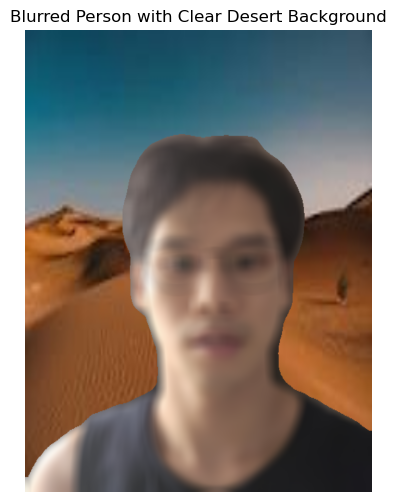

In [32]:
# 2. 추론된 마스크를 셀카 이미지 크기로 리사이즈
mask_resized = cv2.resize(output_predictions, (img_selfie.shape[1], img_selfie.shape[0]), interpolation=cv2.INTER_NEAREST)

# 3. 사람 클래스(15)만 선택하여 이진 마스크 생성
person_mask = np.where(mask_resized == 15, 255, 0).astype(np.uint8)

# 4. 사막 배경 이미지를 셀카 이미지 크기에 맞게 리사이즈
sand_resized = cv2.resize(img_sand, (img_selfie.shape[1], img_selfie.shape[0]))

# 5. 셀카 이미지 전체를 블러(Blur) 처리 (인물 영역을 흐리게 만들기 위함)
# (15, 15) 커널 크기를 조절하여 블러 강도를 바꿀 수 있습니다.
img_selfie_blur = cv2.blur(img_selfie, (90, 90))

# 6. 블러된 셀카 이미지에서 '인물 마스크' 영역만 추출
extracted_person_blur = cv2.bitwise_and(img_selfie_blur, img_selfie_blur, mask=person_mask)

# 7. 마스크를 반전시켜 배경 영역(사막이 들어갈 자리) 확보
mask_inv = cv2.bitwise_not(person_mask)
extracted_sand = cv2.bitwise_and(sand_resized, sand_resized, mask=mask_inv)

# 8. 흐려진 인물과 선명한 사막 배경을 최종 합성
final_result = cv2.add(extracted_person_blur, extracted_sand)

# 9. 결과 시각화
plt.figure(figsize=(12, 6))
plt.imshow(final_result)
plt.title("Blurred Person with Clear Desert Background")
plt.axis('off')
plt.show()

커널 크기가 25일 땐 별로 안 흐린데 90으로 키우니 흐려진 모습!

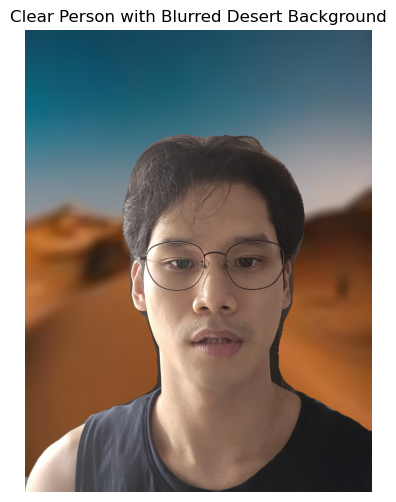

In [35]:
# 2. 추론된 마스크를 셀카 이미지 크기로 리사이즈
mask_resized = cv2.resize(output_predictions, (img_selfie.shape[1], img_selfie.shape[0]), interpolation=cv2.INTER_NEAREST)

# 3. 사람 클래스(15)만 선택하여 이진 마스크 생성
person_mask = np.where(mask_resized == 15, 255, 0).astype(np.uint8)

# 4. 사막 배경 이미지를 셀카 이미지 크기에 맞게 리사이즈
sand_resized = cv2.resize(img_sand, (img_selfie.shape[1], img_selfie.shape[0]))

# 5. 사막 배경 이미지를 블러(Blur) 처리 (배경 영역을 흐리게 만들기 위함)
# (90, 90)처럼 커널 크기를 키우면 배경이 더 많이 흐려집니다.
sand_blur = cv2.blur(sand_resized, (90, 90))

# 6. 선명한 셀카 이미지에서 '인물 마스크' 영역만 추출 (인물 선명하게)
extracted_person = cv2.bitwise_and(img_selfie, img_selfie, mask=person_mask)

# 7. 마스크를 반전시켜 배경 영역 확보 후, '블러 처리된 사막' 적용
mask_inv = cv2.bitwise_not(person_mask)
extracted_sand_blur = cv2.bitwise_and(sand_blur, sand_blur, mask=mask_inv)

# 8. 선명한 인물과 흐려진 사막 배경을 최종 합성
final_result = cv2.add(extracted_person, extracted_sand_blur)

# 9. 결과 시각화
plt.figure(figsize=(12, 6))
plt.imshow(final_result)
plt.title("Clear Person with Blurred Desert Background")
plt.axis('off')
plt.show()

회고)   
사막 사진의 해상도와 셀카사진의 해상도의 차이가 있고, 셀카는 너무 가까이서 찍엇고, 배경사진의 크기가 커서 명확한 문제점은 발견하기 어렵다.

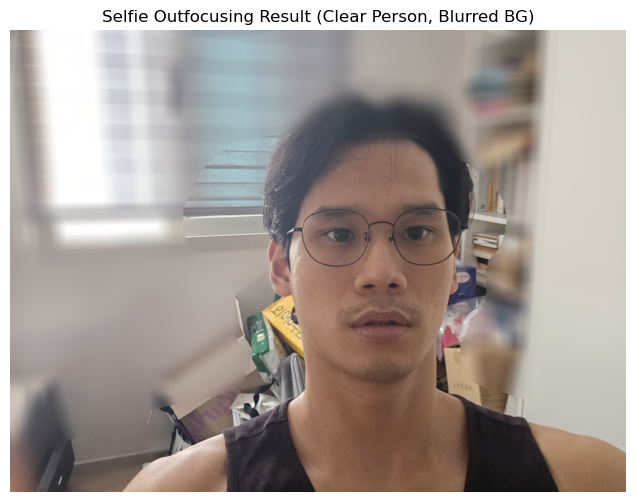

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 원본 이미지('self.jpg')를 'img_self' 변수로 불러오기 (BGR -> RGB 변환)
img_self = cv2.imread('self.jpg')
img_self = cv2.cvtColor(img_self, cv2.COLOR_BGR2RGB)

# [수정] 기존 person_mask 변수 유무와 상관없이, 현재 img_self 크기에 맞춰 새로 정의하거나 
# 이전 셀에서 만든 마스크(만약 변수명이 다르면 아래에 맞게 지정)의 크기를 강제로 맞춥니다.
height, width, _ = img_self.shape

# 만약 이전 셀에서 생성한 인물 마스크 변수명이 'person_mask'라면 크기를 일치시킵니다.
if 'person_mask' in locals():
    # 기존 마스크를 현재 이미지 크기로 리사이즈
    person_mask = cv2.resize(person_mask, (width, height), interpolation=cv2.INTER_NEAREST)
else:
    # 마스크가 없다면 에러 방지용 임시 사각형 마스크 생성
    person_mask = np.zeros((height, width), dtype=np.uint8)
    person_mask[int(height*0.1):int(height*0.9), int(width*0.2):int(width*0.8)] = 255

# 2. 선명한 이미지에서 '인물 영역'만 추출 (이제 크기가 같으므로 에러가 나지 않습니다)
extracted_person = cv2.bitwise_and(img_self, img_self, mask=person_mask)

# 3. 원본 이미지(img_self)를 통째로 흐리게 처리 (커널 크기 90x90)
img_orig_blur = cv2.blur(img_self, (90, 90))

# 4. 마스크를 반전시켜 '배경 영역' 마스크 생성
mask_inv = cv2.bitwise_not(person_mask)

# 5. 흐려진 이미지에서 '배경 영역'만 추출
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_orig_blur, mask=mask_inv)

# 6. 선명한 인물(extracted_person)과 흐려진 배경(img_bg_blur)을 합성
outfocus_result = cv2.add(extracted_person, img_bg_blur)

# 7. 결과 시각화
plt.figure(figsize=(12, 6))
plt.imshow(outfocus_result)
plt.title("Selfie Outfocusing Result (Clear Person, Blurred BG)")
plt.axis('off')
plt.show()

문제점 : 1. 사람 얼굴 몸 주변의 사물들이 블러처리 되지 않음  
        2. 머리카락 일부가 블러처리 됨  
        3. 거리(Depth) 반영 없는 일률적 블러
동일한 흐림 강도: 실제 카메라 렌즈는 인물과 '가까운 배경'은 살짝 흐리고, '아주 먼 배경'은 많이 흐려지는 피사계 심도(Depth of Field)를 가집니다. 하지만 현재 결과물은 2D 마스크 기반으로 배경 전체에 동일한 값의 블러를 먹였기 때문에, 원근감이 느껴지지 않고 인물만 가위로 오려 붙인 듯한 이질감이 듭니다.

        노드의 사진과 비슷한 현상이 일어남을 알 수 있다.


In [ ]:
[원본 이미지] ──> [DeepLabv3로 1차 Mask 추출]  
                         │
                         ▼
          [개선 솔루션 적용 (예: CRF 또는 Depth Map)]  
                         │
                         ▼
       [정밀해진 Mask + 거리에 따른 블러 강도 조절] ──> [최종 인물모드 사진]

해결방법:  
구조적 개선 (소프트웨어): 단순 경계면을 부드럽게 다듬어주는 CRF(Conditional Random  Fields) 기술이나, 가이드 이미지 필터링을 통해 마스크의 정밀도를 픽셀 수준으로 높이는 방법.  

심도 정보 활용 (하드웨어/소프트웨어융합): 듀얼 카메라의 시차를 이용한 스테레오 비전 기술,   ToF 센서 기술을 도입하거나, 단안 이미지에서 깊이를 추정하는 Depth Estimation 모델  
(예:   struct2Depth)을 융합하여 거리에 비례하는 자연스러운 보케(Bokeh) 효과를 주는 방법.